****
**1. Install Required Libraries**
****

In [34]:
!pip install tensorflow matplotlib scikit-learn


****
**2. Mount Google Drive**
****

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


****
**3. Define Dataset Paths**
****

In [36]:
TRAIN_DIR = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/test'
VAL_DIR   = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/val'

****
**4. Verify Dataset Structure**
****

In [37]:
import os
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.listdir(TRAIN_DIR))

True
True
['NORMAL', 'PNEUMONIA']


****
**5. Create a Sample Dataset of 200, 500, 700, 1000 Images**
****

In [49]:

import os
import shutil
import random

DATASET_SIZE = 1000   # Change to 200, 500, 700, 1000 later

SOURCE_TRAIN = "/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train"
TARGET = "/content/sample_dataset"

if os.path.exists(TARGET):
    shutil.rmtree(TARGET)

os.makedirs(f"{TARGET}/NORMAL")
os.makedirs(f"{TARGET}/PNEUMONIA")

normal_count = DATASET_SIZE // 2
pneumonia_count = DATASET_SIZE // 2

normal_images = os.listdir(f"{SOURCE_TRAIN}/NORMAL")
pneumonia_images = os.listdir(f"{SOURCE_TRAIN}/PNEUMONIA")

selected_normal = random.sample(normal_images, normal_count)
selected_pneumonia = random.sample(pneumonia_images, pneumonia_count)

for img in selected_normal:
    shutil.copy(
        f"{SOURCE_TRAIN}/NORMAL/{img}",
        f"{TARGET}/NORMAL/{img}"
    )

for img in selected_pneumonia:
    shutil.copy(
        f"{SOURCE_TRAIN}/PNEUMONIA/{img}",
        f"{TARGET}/PNEUMONIA/{img}"
    )

print(f"Dataset created with {DATASET_SIZE} images")


Dataset created with 1000 images


****
**6. Verify Sample Dataset**
****


In [50]:
import os

print("NORMAL:", len(os.listdir("/content/sample_dataset/NORMAL")))
print("PNEUMONIA:", len(os.listdir("/content/sample_dataset/PNEUMONIA")))

NORMAL: 500
PNEUMONIA: 500


****
**7. Load Dataset**
****


In [51]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


****
**Check Dataset Size**
****

In [52]:
print("Training batches:", len(train_ds))
print("Testing batches:", len(test_ds))

Training batches: 100
Testing batches: 25


****
**9. ResNet50 **
****


In [53]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

****
**10. Compile Model**
****


In [54]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 compiled successfully")

ResNet50 compiled successfully


****
**11. Train Model**
****


In [ ]:

import time

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

end_time = time.time()

training_time = end_time - start_time

print("Training Time:", round(training_time,2), "seconds")


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.7788 - loss: 0.5733 - val_accuracy: 0.7150 - val_loss: 0.5746
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.7625 - loss: 0.5667 - val_accuracy: 0.7600 - val_loss: 0.5556
Epoch 3/5


****
**12. Evaluate Model**
****


In [57]:

loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

print("\n----- RESULTS -----")
print("Model Name: ResNet50")
print("Dataset Size:", DATASET_SIZE)
print("Training Time:", round(training_time,2), "seconds")
print("Accuracy:", round(float(accuracy),4))
print("Loss:", round(float(loss),4))


25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7950 - loss: 0.5791
Test Loss: 0.5791250467300415
Test Accuracy: 0.7950000166893005

----- RESULTS -----
Model Name: ResNet50
Dataset Size: 1000
Training Time: 898.55 seconds
Accuracy: 0.795
Loss: 0.5791


****
**13. Accuracy Graph**
****


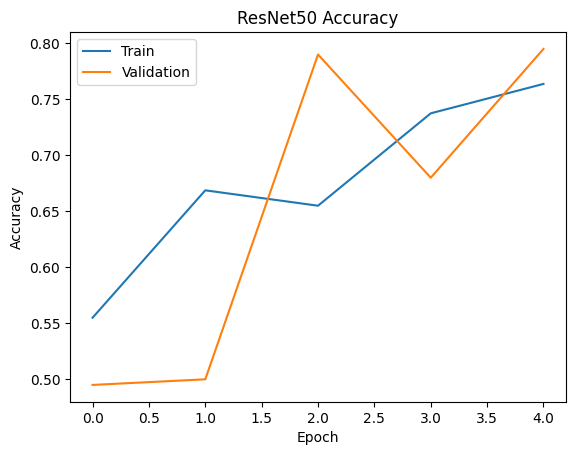

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

****
**14. Loss Graph**
****

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

****
**15. Save the Model**
****

In [ ]:
model.save('resnet50_pneumonia_model.h5')